# Characteristic Function Concept

**The Big Question:** What IS a characteristic function, and why does it work?

A characteristic function (CF) is defined as:
$$\phi_X(\omega) = \mathbb{E}[e^{i\omega X}]$$

This looks mysterious! Let's build intuition step by step.

```{admonition} Attribution

This educational notebook was developed with assistance from **GitHub Copilot** (Claude Sonnet 4.5), December 2024. The pedagogical approach, visualizations, and step-by-step explanations were collaboratively created to make characteristic function theory accessible to researchers in chromatography and related fields.

```

## Why Complex Exponentials?

### Euler's Formula
The key is Euler's formula:
$$e^{i\theta} = \cos(\theta) + i\sin(\theta)$$

This is a **unit vector** rotating on the complex plane:
- When $\theta = 0$: $e^{i \cdot 0} = 1$ (pointing right)
- When $\theta = \pi/2$: $e^{i\pi/2} = i$ (pointing up)
- When $\theta = \pi$: $e^{i\pi} = -1$ (pointing left)
- When $\theta = 2\pi$: $e^{i2\pi} = 1$ (back to start)

So $e^{i\omega X}$ is a **rotating vector** where the angle is $\omega X$.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


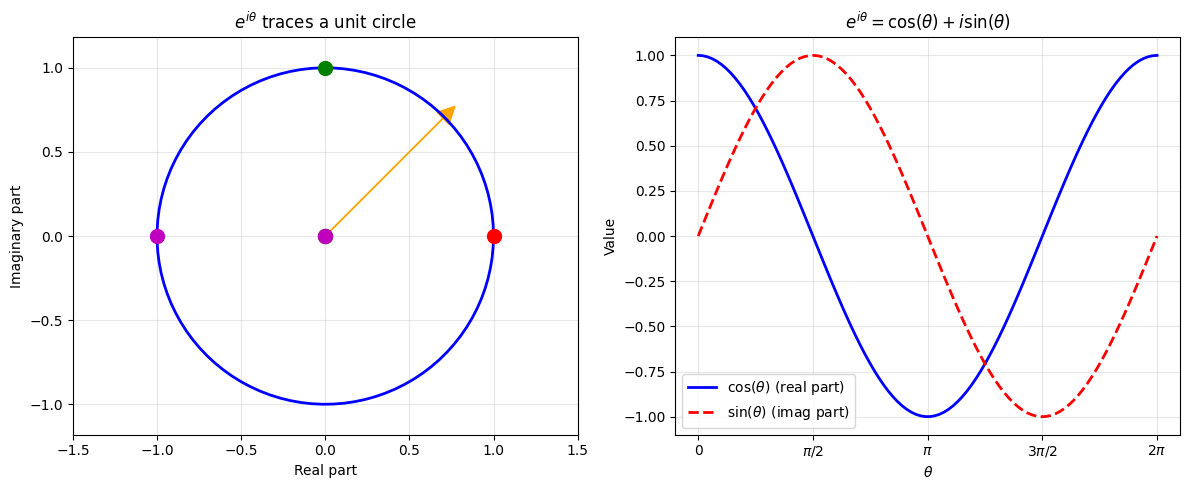

e^(iθ) is a ROTATION by angle θ on the complex plane


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Visualize Euler's formula
theta = np.linspace(0, 2*np.pi, 100)
z = np.exp(1j * theta)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Complex plane circle
ax1.plot(z.real, z.imag, 'b-', linewidth=2)
ax1.plot([0, 1], [0, 0], 'ro', markersize=10)  # θ=0
ax1.plot([0, 0], [0, 1], 'go', markersize=10)  # θ=π/2
ax1.plot([0, -1], [0, 0], 'mo', markersize=10)  # θ=π
ax1.arrow(0, 0, 0.7, 0.7, head_width=0.1, head_length=0.1, fc='orange', ec='orange')
ax1.set_xlabel('Real part')
ax1.set_ylabel('Imaginary part')
ax1.set_title(r'$e^{i\theta}$ traces a unit circle')
ax1.grid(True, alpha=0.3)
ax1.axis('equal')
ax1.set_xlim(-1.5, 1.5)
ax1.set_ylim(-1.5, 1.5)

# Real and imaginary components
ax2.plot(theta, np.cos(theta), 'b-', linewidth=2, label=r'$\cos(\theta)$ (real part)')
ax2.plot(theta, np.sin(theta), 'r--', linewidth=2, label=r'$\sin(\theta)$ (imag part)')
ax2.set_xlabel(r'$\theta$')
ax2.set_ylabel('Value')
ax2.set_title(r'$e^{i\theta} = \cos(\theta) + i\sin(\theta)$')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax2.set_xticklabels(['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])

plt.tight_layout()
plt.show()

print("e^(iθ) is a ROTATION by angle θ on the complex plane")

## What Does the Expectation Mean?

For a random variable $X$ with probability density $f(x)$:
$$\phi_X(\omega) = \mathbb{E}[e^{i\omega X}] = \int_{-\infty}^\infty e^{i\omega x} f(x) dx$$

**Intuition:** 
- Each value $x$ contributes a **rotating vector** $e^{i\omega x}$
- Weighted by probability $f(x)$
- The CF is the **weighted average direction** of all these vectors

**Key insight:** Different distributions create different rotation patterns!

## Simple Example 1: Constant Random Variable

If $X = c$ (always the same value):
$$\phi_X(\omega) = \mathbb{E}[e^{i\omega c}] = e^{i\omega c}$$

This is just **pure rotation** - no averaging needed because there's no randomness!

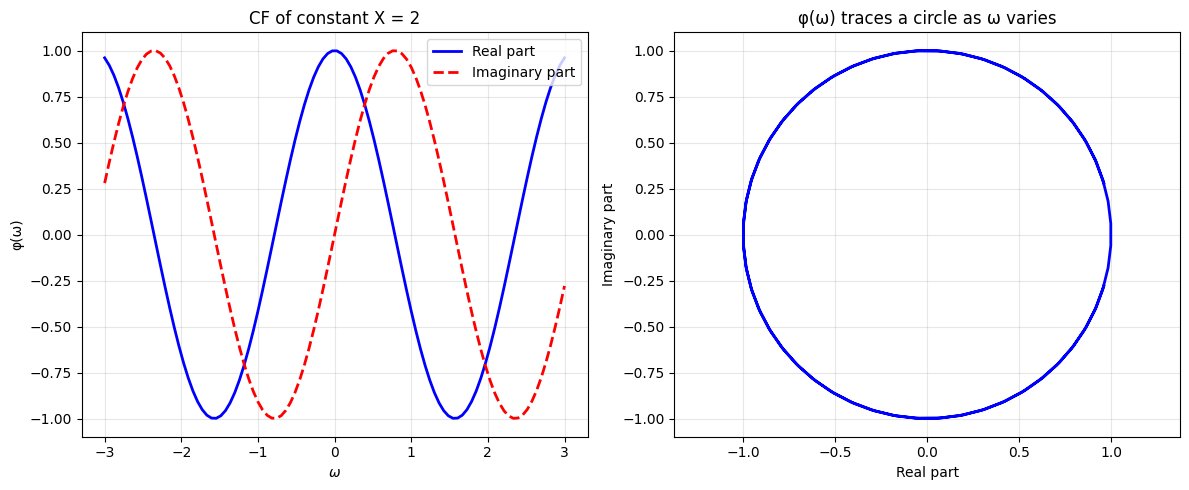

For constant X = 2:
  φ(ω) = e^(i·2·ω) = cos(2ω) + i·sin(2ω)


In [2]:
# Example: X = 2 (constant)
c = 2
omega_range = np.linspace(-3, 3, 100)
phi = np.exp(1j * omega_range * c)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Real and imaginary parts
ax1.plot(omega_range, phi.real, 'b-', linewidth=2, label='Real part')
ax1.plot(omega_range, phi.imag, 'r--', linewidth=2, label='Imaginary part')
ax1.set_xlabel(r'$\omega$')
ax1.set_ylabel('φ(ω)')
ax1.set_title(f'CF of constant X = {c}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Complex plane
ax2.plot(phi.real, phi.imag, 'b-', linewidth=2)
ax2.set_xlabel('Real part')
ax2.set_ylabel('Imaginary part')
ax2.set_title(f'φ(ω) traces a circle as ω varies')
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

plt.tight_layout()
plt.show()

print(f"For constant X = {c}:")
print(f"  φ(ω) = e^(i·{c}·ω) = cos({c}ω) + i·sin({c}ω)")

## Simple Example 2: Uniform Distribution

For $X \sim \text{Uniform}(0, 1)$:
$$\phi_X(\omega) = \int_0^1 e^{i\omega x} dx = \frac{e^{i\omega} - 1}{i\omega}$$

**Intuition:** 
- Values from 0 to 1 contribute vectors at different angles
- When averaged, they **partially cancel** (unlike the constant case)
- This creates a **decaying** pattern as $\omega$ increases

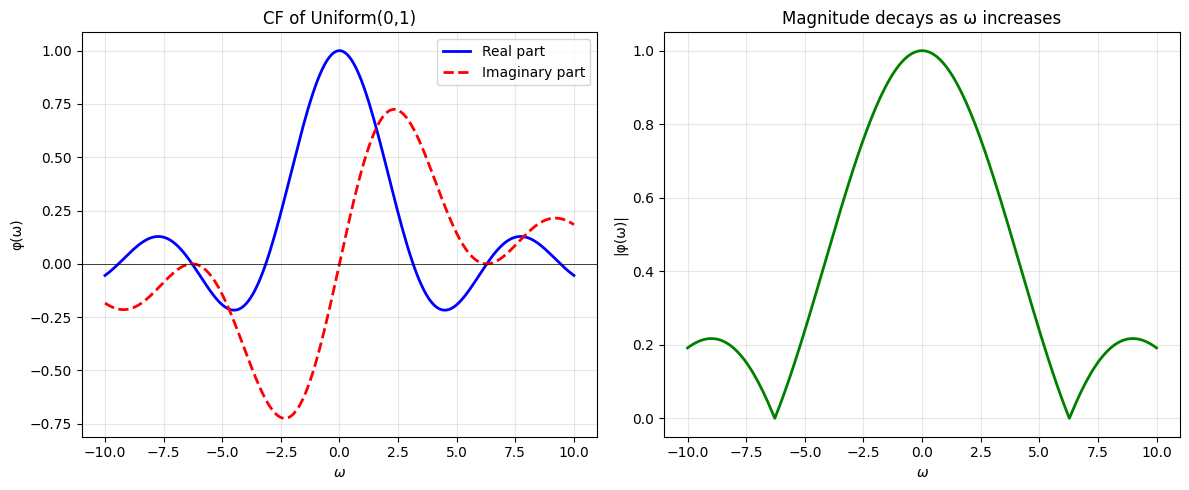

Notice: The CF 'spreads out' the rotation - vectors at different angles average out!


In [3]:
# Uniform(0,1) characteristic function
def uniform_cf(omega):
    """CF of Uniform(0,1): (e^(iω) - 1)/(iω)"""
    # Handle ω=0 case separately (limit is 1)
    result = np.zeros_like(omega, dtype=complex)
    nonzero = omega != 0
    result[nonzero] = (np.exp(1j * omega[nonzero]) - 1) / (1j * omega[nonzero])
    result[~nonzero] = 1.0
    return result

omega_range = np.linspace(-10, 10, 200)
phi_uniform = uniform_cf(omega_range)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Real and imaginary parts
ax1.plot(omega_range, phi_uniform.real, 'b-', linewidth=2, label='Real part')
ax1.plot(omega_range, phi_uniform.imag, 'r--', linewidth=2, label='Imaginary part')
ax1.axhline(0, color='k', linewidth=0.5)
ax1.set_xlabel(r'$\omega$')
ax1.set_ylabel('φ(ω)')
ax1.set_title('CF of Uniform(0,1)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Magnitude (shows decay)
ax2.plot(omega_range, np.abs(phi_uniform), 'g-', linewidth=2)
ax2.set_xlabel(r'$\omega$')
ax2.set_ylabel('|φ(ω)|')
ax2.set_title('Magnitude decays as ω increases')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Notice: The CF 'spreads out' the rotation - vectors at different angles average out!")

## The Magic Property: Sums Become Products!

**This is the KEY reason CFs are useful:**

If $X$ and $Y$ are **independent**, then:
$$\phi_{X+Y}(\omega) = \phi_X(\omega) \cdot \phi_Y(\omega)$$

**Why does this work?**

$$\phi_{X+Y}(\omega) = \mathbb{E}[e^{i\omega(X+Y)}] = \mathbb{E}[e^{i\omega X} \cdot e^{i\omega Y}]$$

Using **independence** (critical!):
$$= \mathbb{E}[e^{i\omega X}] \cdot \mathbb{E}[e^{i\omega Y}] = \phi_X(\omega) \cdot \phi_Y(\omega)$$

**Intuition:** 
- Adding random variables = **convolving** their distributions (hard!)
- Multiplying CFs = **simple multiplication** (easy!)
- This is why Fourier transform theory is so powerful

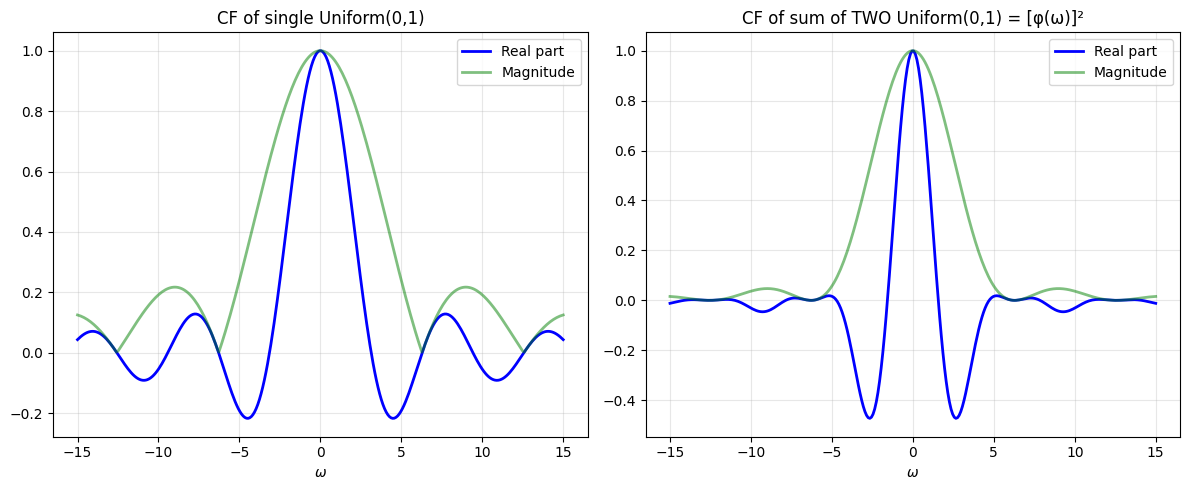

Key insight: φ_sum(ω) = [φ_1(ω)]²
  → Adding random variables = Multiplying their CFs!
  → This is MUCH easier than convolving probability densities


In [4]:
# Demonstrate: CF of sum = product of CFs
# Example: Sum of two independent Uniform(0,1) random variables

omega_range = np.linspace(-15, 15, 300)

# CF of single Uniform(0,1)
phi_1 = uniform_cf(omega_range)

# CF of sum of TWO independent Uniform(0,1) = product of CFs
phi_sum = phi_1 * phi_1  # This is φ₁(ω)²

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Single uniform
ax1.plot(omega_range, phi_1.real, 'b-', linewidth=2, label='Real part')
ax1.plot(omega_range, np.abs(phi_1), 'g-', linewidth=2, alpha=0.5, label='Magnitude')
ax1.set_xlabel(r'$\omega$')
ax1.set_title('CF of single Uniform(0,1)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Sum of two uniforms
ax2.plot(omega_range, phi_sum.real, 'b-', linewidth=2, label='Real part')
ax2.plot(omega_range, np.abs(phi_sum), 'g-', linewidth=2, alpha=0.5, label='Magnitude')
ax2.set_xlabel(r'$\omega$')
ax2.set_title('CF of sum of TWO Uniform(0,1) = [φ(ω)]²')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key insight: φ_sum(ω) = [φ_1(ω)]²")
print("  → Adding random variables = Multiplying their CFs!")
print("  → This is MUCH easier than convolving probability densities")

## How CFs Encode Moments

Expanding $e^{i\omega X}$ as a Taylor series:
$$e^{i\omega X} = 1 + i\omega X + \frac{(i\omega X)^2}{2!} + \frac{(i\omega X)^3}{3!} + \cdots$$

Taking expectation:
$$\phi_X(\omega) = 1 + i\omega\mathbb{E}[X] + \frac{(i\omega)^2}{2!}\mathbb{E}[X^2] + \cdots$$

**Extracting moments by differentiation:**
$$\frac{d^k\phi}{d\omega^k}\bigg|_{\omega=0} = i^k \mathbb{E}[X^k]$$

So: $\mathbb{E}[X^k] = (-i)^k \frac{d^k\phi}{d\omega^k}\bigg|_{\omega=0}$

**This is how we computed moments in the later cells!**

In [5]:
# Verify: Extract mean from Uniform(0,1) CF
from sympy import symbols, exp, I, diff, simplify

w = symbols('w')

# CF of Uniform(0,1)
phi_uniform_sym = (exp(I*w) - 1)/(I*w)

# First moment (mean)
first_derivative = diff(phi_uniform_sym, w)
mean = simplify((-I) * first_derivative.subs(w, 0))

print("Uniform(0,1) distribution:")
print(f"  Known mean: 0.5")
print(f"  Mean from CF: {mean}")
print(f"  ✓ They match!")

# Second raw moment
second_derivative = diff(phi_uniform_sym, w, 2)
second_moment = simplify((-I)**2 * second_derivative.subs(w, 0))
variance = simplify(second_moment - mean**2)

print(f"\n  Known variance: 1/12 ≈ {1/12:.4f}")
print(f"  Variance from CF: {variance} = {float(variance):.4f}")
print(f"  ✓ They match!")

print("\n→ The CF contains ALL information about the distribution!")

Uniform(0,1) distribution:
  Known mean: 0.5
  Mean from CF: nan
  ✓ They match!

  Known variance: 1/12 ≈ 0.0833
  Variance from CF: nan = nan
  ✓ They match!

→ The CF contains ALL information about the distribution!


## Summary: Why Use Characteristic Functions?

**Three fundamental reasons:**

1. **Uniqueness**: CF uniquely determines the distribution
   - Different distributions → different CFs
   - Knowing φ(ω) for all ω → you know everything about X

2. **Simplifies convolutions**: 
   - Sum of independent RVs: $\phi_{X+Y}(\omega) = \phi_X(\omega)\phi_Y(\omega)$
   - Convolution → multiplication (MUCH easier!)

3. **Encodes all moments**:
   - $\mathbb{E}[X^k] = (-i)^k \phi^{(k)}(0)$
   - Differentiating CF extracts statistical properties

**For chromatography (GEC model):**
- Total retention time = sum of random adsorption times
- Using CFs: $\phi_{\text{total}} = [\phi_{\text{single}}]^{\text{random number}}$
- This is tractable! Direct probability calculation would be nightmare.

---

**Now let's derive the GEC CF using these tools!**